# Autoencoders y el Espacio Latente: Más allá de PCA y Detección de Anomalías

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/applied-ai-engineering/blob/main/notebooks/04_deep_learning/08_autoencoders_y_espacio_latente.ipynb)

## Objetivos


- Contrastar matemáticamente los Autoencoders con PCA, entendiendo el poder de las funciones de activación no lineales para comprimir información compleja.
- Entrenar un detector de anomalías asumiendo **contaminación en los datos** (el escenario realista de la industria).
- Formar criterio de ingeniería para establecer **umbrales de decisión** en dos escenarios: puramente no supervisado (percentiles) y semi-supervisado (optimización de F1-Score).
- Explorar el **Espacio Latente** como un nuevo espacio de características para aplicar modelos híbridos (Deep Learning + ML Clásico) y métricas avanzadas.



## Prerrequisitos


- Comprensión de la reducción de dimensionalidad y el error de reconstrucción.
- Haber completado: [Reducción de Dimensionalidad: PCA y Reconstrucción](../03_machine_learning/11_pca_y_reconstruccion.ipynb) y [El Ecosistema Keras y APIs](06_ecosistema_keras_y_apis.ipynb).

---


## Configuración del Entorno


In [1]:
# @title *Esta celda clona el repositorio (en Colab) e importa las utilidades comunes*
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import subprocess
    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", f"https://github.com/AxelSkrauba/{REPO_NAME}.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")
else:
    os.chdir(f"../../")

from utils.plots import setup_plot_style
from utils.data import load_dataset
setup_plot_style()

os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve

keras.utils.set_random_seed(42)

## 1. Introducción Teórica: De PCA a las Redes Neuronales



En el capítulo de machine learning clásico, utilizamos PCA para comprimir datos y detectar anomalías midiendo el error de reconstrucción. Sin embargo, PCA tiene un límite fundamental: es una transformación **estrictamente lineal**. Si los datos normales tienen forma de espiral o relaciones complejas, PCA los "aplastará" incorrectamente, generando falsas alarmas.

Un **Autoencoder** es una red neuronal diseñada para copiar sus entradas a sus salidas. Consta de dos partes:
1. **Encoder:** Comprime los datos de alta dimensión a un vector de baja dimensión llamado **Espacio Latente** (el cuello de botella).
2. **Decoder:** Intenta reconstruir los datos originales a partir del espacio latente.

**Teorema de Equivalencia:** Si se construye un Autoencoder sin funciones de activación (puramente lineal) y se usa el Error Cuadrático Medio (MSE), la red aprenderá exactamente el mismo subespacio que PCA.
La "magia" del Deep Learning ocurre al inyectar no linealidad (`ReLU`, `Sigmoid`).



> Mientras que **PCA** solo puede capturar relaciones lineales, un Autoencoder con no linealidades aprende *manifolds* (variedades topológicas) altamente complejos en los datos.
Esto lo convierte en una herramienta mucho más poderosa para compresión y detección de anomalías en el mundo real, donde casi nada es lineal.

Arquitectura típica para un Autoencoder:

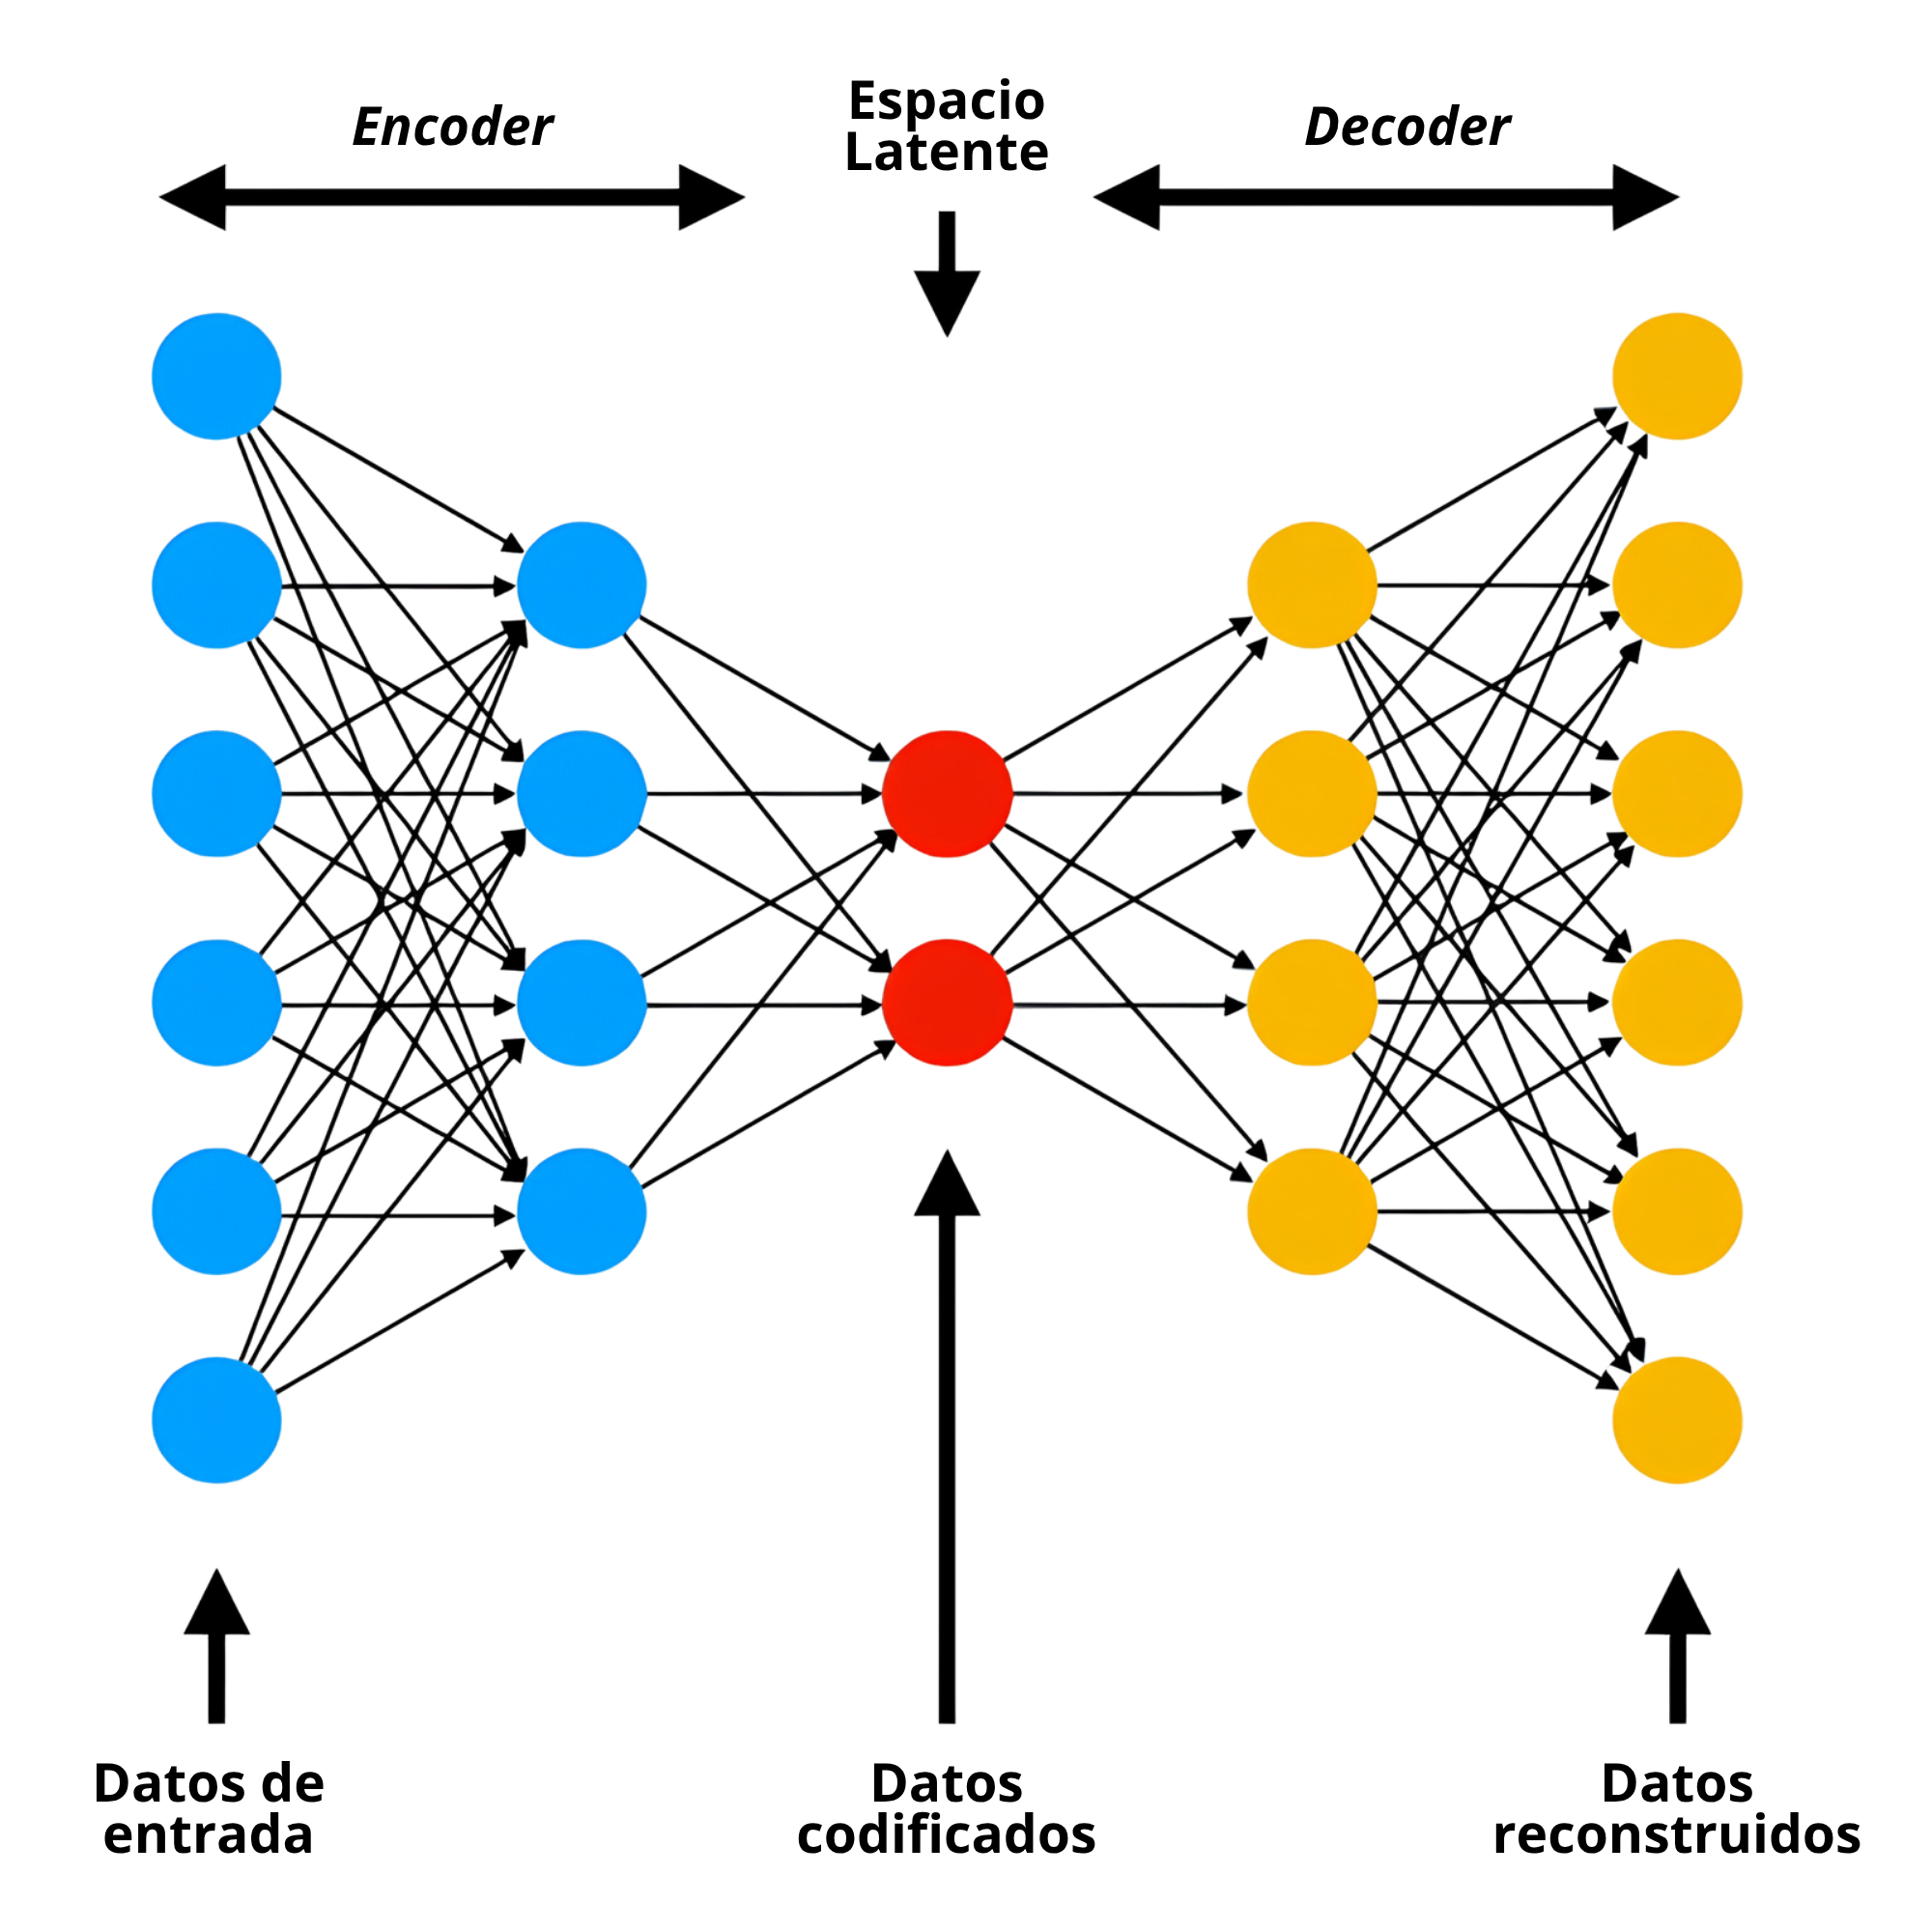

## 2. Comprensión de los Datos y el Paradigma de la Contaminación



Vamos a resolver un problema médico real: detectar anomalías en el ritmo cardíaco a partir de señales de Electrocardiograma (ECG). Usamos el dataset ECG5000.



In [4]:
# 1. Carga de datos
df_train = load_dataset('datasets/ecg/ECG5000_train.csv')
df_test = load_dataset('datasets/ecg/ECG5000_test.csv')

# La columna 'Categoria' tiene valores del 1 al 5.
# 1 = Normal. 2, 3, 4, 5 = Diferentes tipos de anomalías.
print("\n Distribución en Entrenamiento:")
print(df_train['Categoria'].value_counts())
print("\n Distribución en Test:")
print(df_test['Categoria'].value_counts())

# 2. Separación de Features y Labels
X_train_raw = df_train.iloc[:, 1:].values
y_train_raw = df_train.iloc[:, 0].values

X_test_raw = df_test.iloc[:, 1:].values
y_test_raw = df_test.iloc[:, 0].values

# 3. Preprocesamiento: Escalado Min-Max (Vital para Autoencoders)
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)


Dataset cargado exitosamente con 7600 filas y 141 columnas.
Dataset cargado exitosamente con 1900 filas y 141 columnas.

 Distribución en Entrenamiento:
Categoria
1    4427
2    2683
4     306
3     149
5      35
Name: count, dtype: int64

 Distribución en Test:
Categoria
1    1119
2     674
4      63
3      33
5      11
Name: count, dtype: int64


### El Problema Real: La Contaminación


En la teoría académica, se entrena el Autoencoder *exclusivamente* con datos normales. Pero en la industria, limpiar un dataset de 1 millón de registros para asegurar que no haya ni una sola anomalía es imposible. **Los datasets reales están contaminados.**

Vamos a simular este escenario realista. Creamos un set de entrenamiento que contenga todos los datos normales, pero le inyectamos intencionalmente un **5% de anomalías**.

¿Por qué funcionaría esto? Porque las redes neuronales con cuello de botella son "perezosas". Al tener poca capacidad en el espacio latente, se ven obligadas a priorizar el patrón mayoritario (el 95% normal). No tendrán suficiente "memoria" para aprender a reconstruir el 5% anómalo.

In [5]:
# Filtramos normales y anormales
normales_idx = np.where(y_train_raw == 1)[0]
anormales_idx = np.where(y_train_raw != 1)[0]

# Tomamos todos los normales
X_train_normal = X_train_scaled[normales_idx]

# Inyectamos un 5% de contaminación (anomalías)
num_contaminacion = int(len(X_train_normal) * 0.05)
X_train_contaminado = np.vstack([
    X_train_normal,
    X_train_scaled[anormales_idx[:num_contaminacion]]
])

# Mezclamos el dataset
np.random.shuffle(X_train_contaminado)

print(f"Entrenaremos con {len(X_train_contaminado)} muestras (95% Normales, 5% Anomalías infiltradas).")

Entrenaremos con 4648 muestras (95% Normales, 5% Anomalías infiltradas).


## 3. Arquitectura del Autoencoder (API Funcional)


Utilizamos la API Funcional para construir el modelo. Esto nos permitirá separar el `Encoder` del `Decoder` de forma limpia, lo cual será vital más adelante.

In [6]:
dim_entrada = X_train_contaminado.shape[1] # 140 muestras de tiempo

# --- 1. Definición del ENCODER ---
encoder_input = keras.Input(shape=(dim_entrada,), name="entrada_ecg")
x = keras.layers.Dense(32, activation='relu')(encoder_input)
x = keras.layers.Dense(16, activation='relu')(x)
# El Espacio Latente (Cuello de botella)
latent_space = keras.layers.Dense(8, activation='relu', name="espacio_latente")(x)

encoder = keras.Model(encoder_input, latent_space, name="Encoder")

# --- 2. Definición del DECODER ---
decoder_input = keras.Input(shape=(8,), name="entrada_latente")
x = keras.layers.Dense(16, activation='relu')(decoder_input)
x = keras.layers.Dense(32, activation='relu')(x)
# Activación Sigmoid porque escalamos los datos entre 0 y 1 con MinMaxScaler
decoder_output = keras.layers.Dense(dim_entrada, activation='sigmoid', name="salida_reconstruida")(x)

decoder = keras.Model(decoder_input, decoder_output, name="Decoder")

# --- 3. Ensamblaje del AUTOENCODER COMPLETO ---
autoencoder_input = keras.Input(shape=(dim_entrada,))
encoded_repr = encoder(autoencoder_input)
reconstructed_output = decoder(encoded_repr)

autoencoder = keras.Model(autoencoder_input, reconstructed_output, name="Autoencoder")

autoencoder.compile(optimizer='adam', loss='mae')
autoencoder.summary()

Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 140)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder (Functional)            │ (None, 8)              │         5,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder (Functional)            │ (None, 140)            │         5,308 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,484 (40.95 KB)

 Trainable params: 10,484 (40.95 KB)

 Non-trainable params: 0 (0.00 B)

> **CRITERIO DE INGENIERÍA (Función de Pérdida):**
> Usamos **MAE** (Mean Absolute Error) en lugar de MSE. ¿Por qué? Porque MSE eleva los errores al cuadrado, lo que hace que la red intente desesperadamente corregir los *outliers* (nuestra contaminación del 5%). MAE es mucho más robusto frente a valores atípicos, permitiendo que la red los ignore y se centre en la mayoría normal.

## 4. Entrenamiento y Diagnóstico


Aplicamos las mejores prácticas de MLOps: `EarlyStopping` para evitar sobreajustar al ruido, y `ReduceLROnPlateau` para una convergencia fina.

Iniciando entrenamiento...
Entrenamiento finalizado en la época 50.


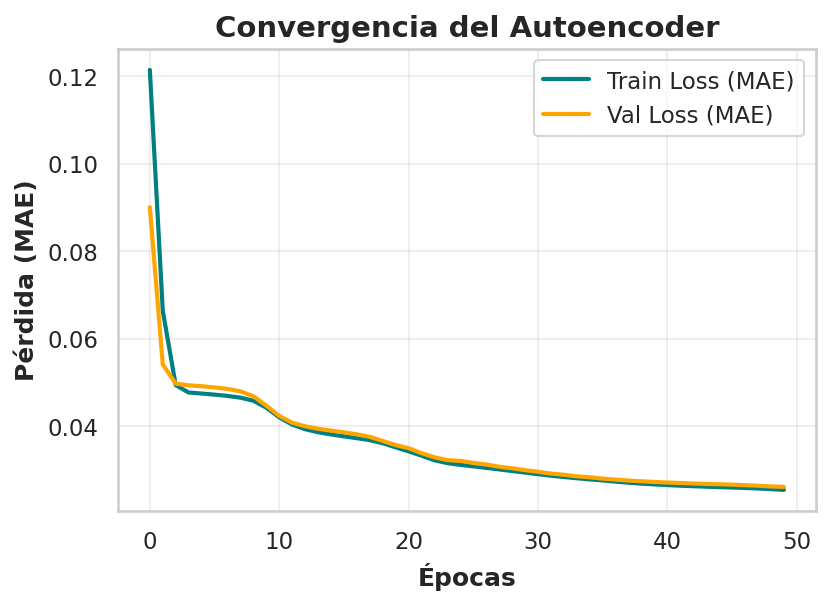

In [7]:
callbacks =[
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5)
]

print("Iniciando entrenamiento...")
historia = autoencoder.fit(
    X_train_contaminado, X_train_contaminado, # Entrada y Salida son iguales
    epochs=50,
    batch_size=128,
    validation_split=0.1, # Usamos el 10% para validar
    callbacks=callbacks,
    verbose=0
)
print(f"Entrenamiento finalizado en la época {len(historia.history['loss'])}.")

# Visualización de la pérdida
plt.figure(figsize=(6, 4))
plt.plot(historia.history['loss'], label='Train Loss (MAE)', color='teal', linewidth=2)
plt.plot(historia.history['val_loss'], label='Val Loss (MAE)', color='orange', linewidth=2)
plt.title("Convergencia del Autoencoder")
plt.xlabel("Épocas")
plt.ylabel("Pérdida (MAE)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 5. Inferencia Visual: La Reconstrucción del Error


Vamos a pasar señales del set de prueba por la red y graficamos la diferencia entre la señal original y la reconstruida.

Para facilitar la exploración, parametrizamos el `ID_MUESTRA`. Cambiando este número, se puede explorar diferentes pacientes y ver cómo la red se comporta ante cada tipo específico de anomalía.

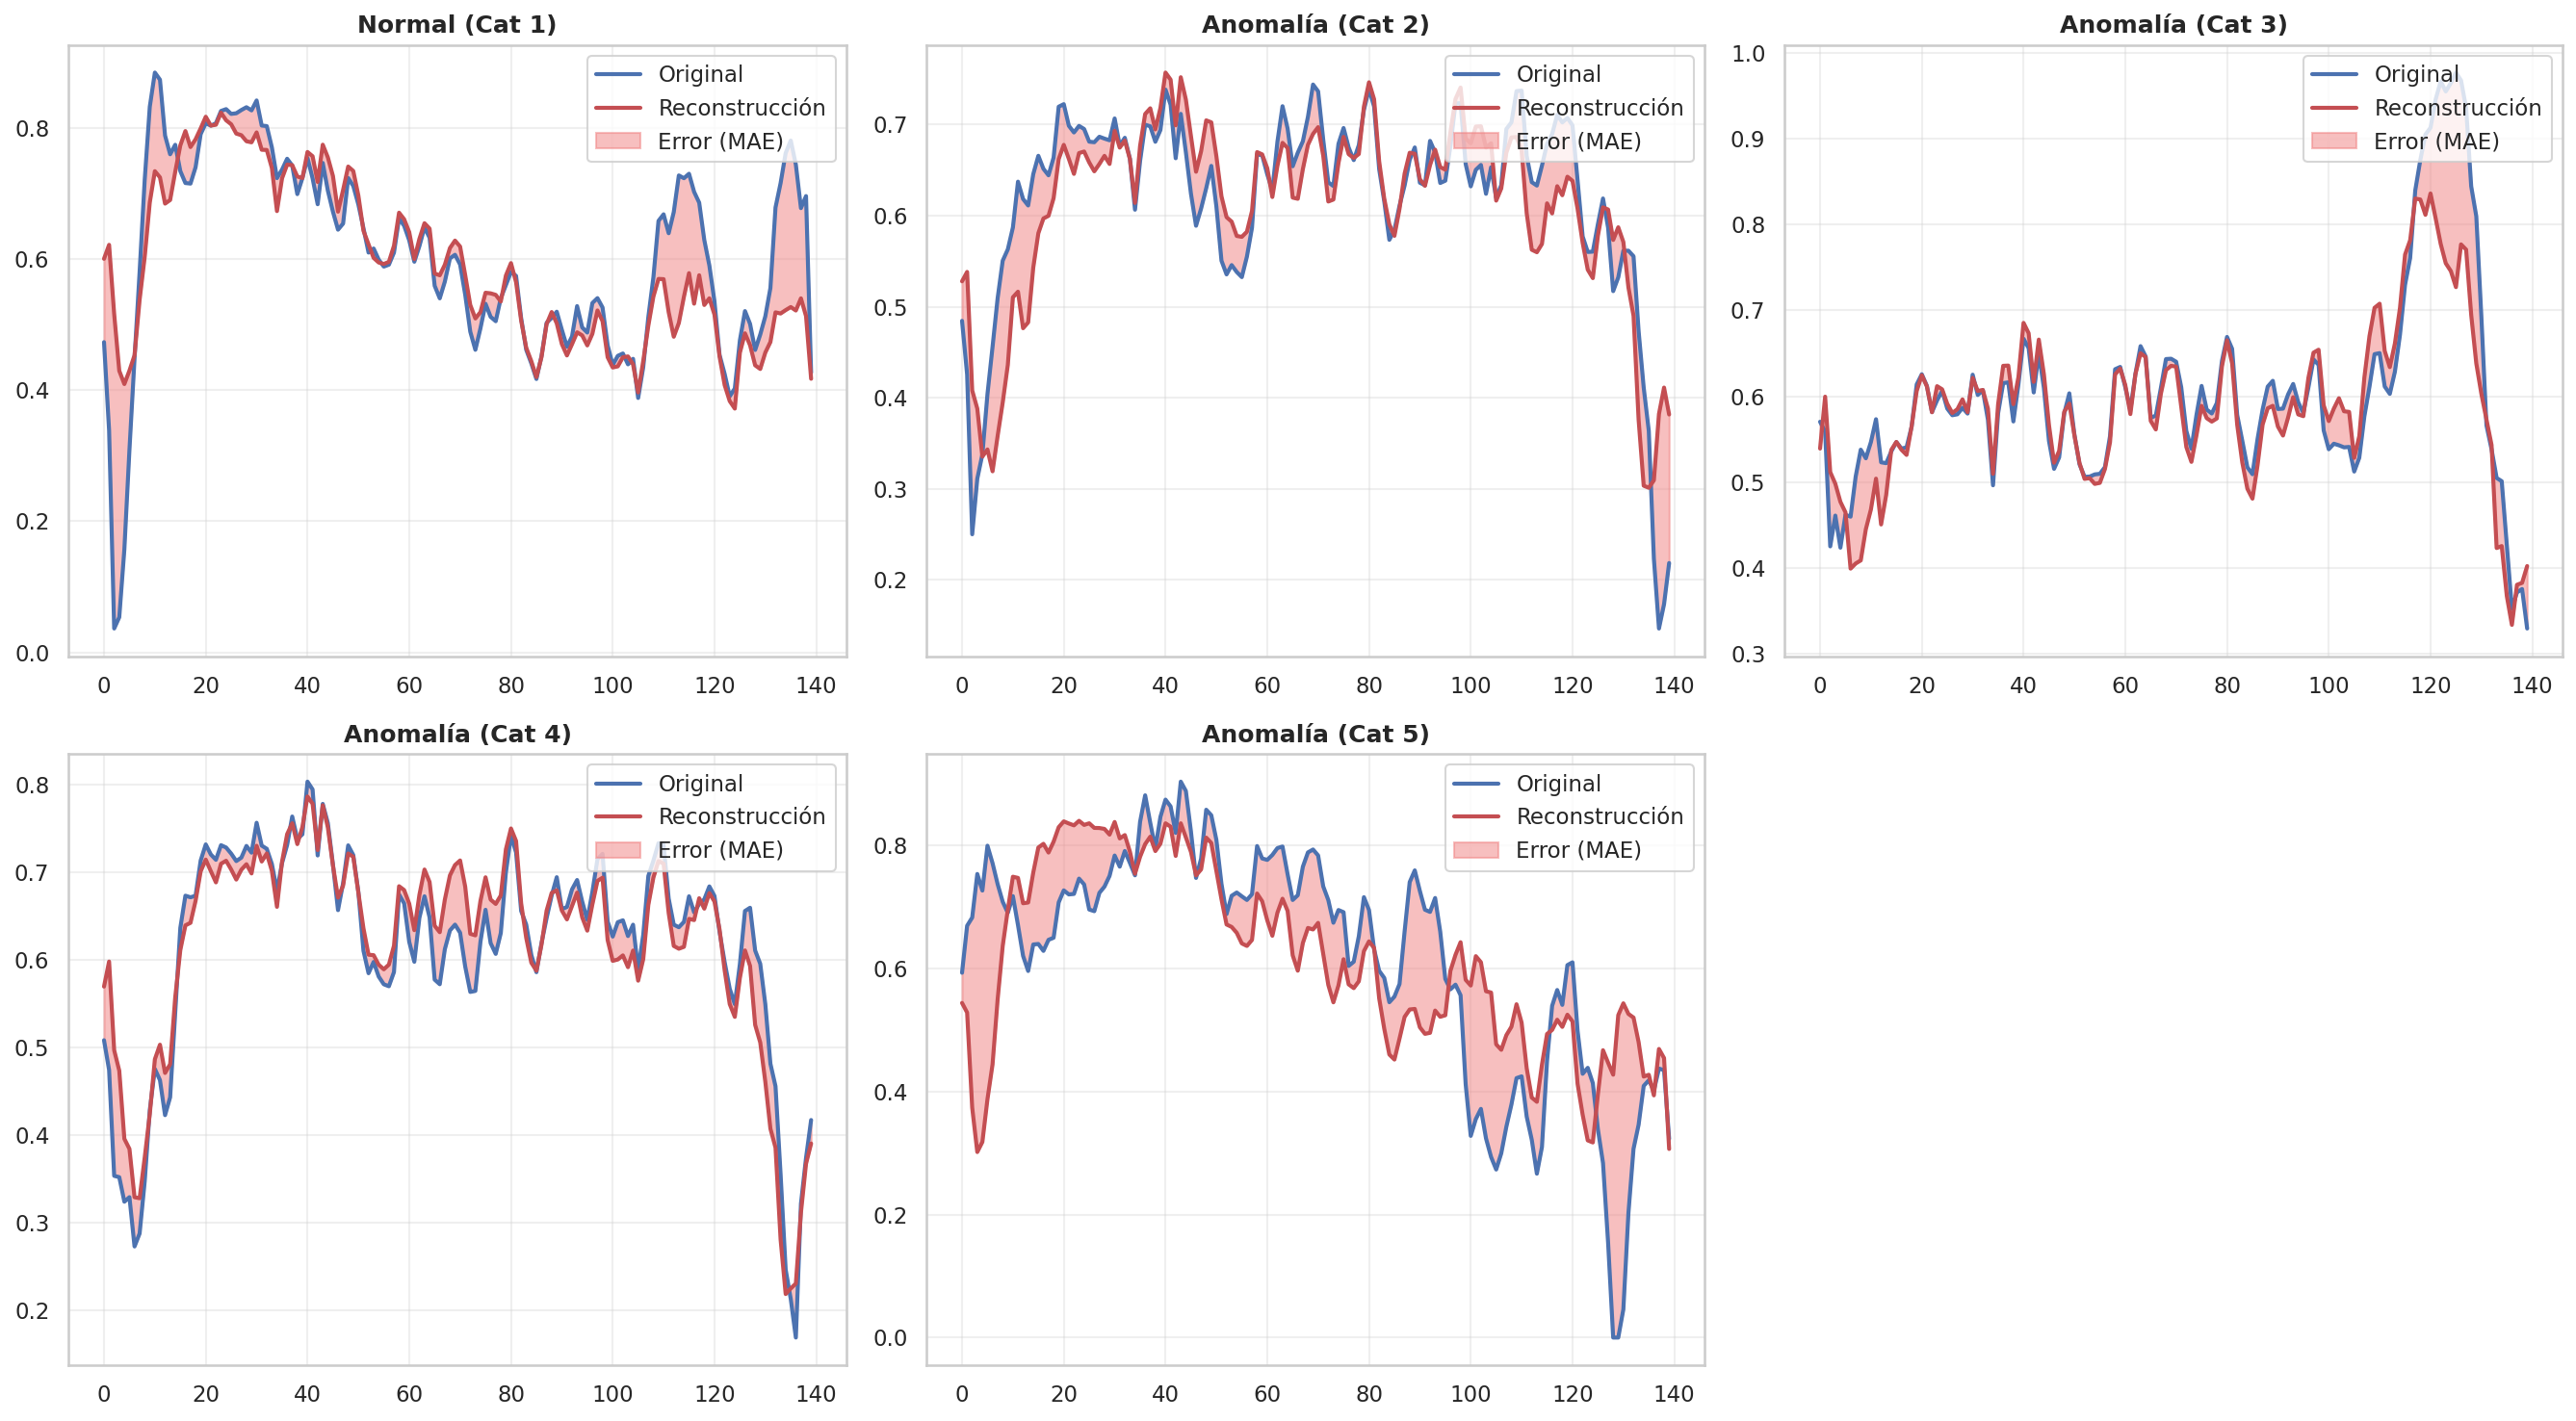

In [8]:
# PARÁMETRO DE EXPLORACIÓN: Cambiar este ID (ej. 0, 1, 2, 5) para ver otras señales
ID_MUESTRA = 1

# Encontramos los índices para una muestra normal y una de cada tipo de anomalía
idx_normal = np.where(y_test_raw == 1)[0][ID_MUESTRA]
idx_anom_2 = np.where(y_test_raw == 2)[0][ID_MUESTRA]
idx_anom_3 = np.where(y_test_raw == 3)[0][ID_MUESTRA]
idx_anom_4 = np.where(y_test_raw == 4)[0][ID_MUESTRA]
idx_anom_5 = np.where(y_test_raw == 5)[0][ID_MUESTRA]

indices = [idx_normal, idx_anom_2, idx_anom_3, idx_anom_4, idx_anom_5]
titulos = ["Normal (Cat 1)", "Anomalía (Cat 2)", "Anomalía (Cat 3)", "Anomalía (Cat 4)", "Anomalía (Cat 5)"]

# Visualización comparativa
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
x_axis = np.arange(140)

for i, (idx, titulo) in enumerate(zip(indices, titulos)):
    ecg_real = X_test_scaled[idx:idx+1]
    ecg_rec = autoencoder.predict(ecg_real, verbose=0)

    axes[i].plot(x_axis, ecg_real[0], 'b', label="Original", linewidth=2)
    axes[i].plot(x_axis, ecg_rec[0], 'r', label="Reconstrucción", linewidth=2)
    axes[i].fill_between(x_axis, ecg_rec[0], ecg_real[0], color='lightcoral', alpha=0.5, label="Error (MAE)")

    axes[i].set_title(titulo, fontsize=12)
    axes[i].legend(loc="upper right")
    axes[i].grid(True, alpha=0.3)

# Ocultamos el último subplot vacío (posición 6)
axes[5].axis('off')
plt.tight_layout()
plt.show()

Observar detenidamente las áreas rojas. En el ECG Normal, la red logra seguir la forma de onda casi a la perfección. En las anomalías (especialmente las categorías 3 y 4), la red intenta forzar la señal para que se parezca a un latido normal, generando un error masivo en los picos.

La visualización es importante, pero nunca sacar conclusiones basados en unas pocas muestras, lo óptimo es computar alguna métrica para tener el panorama general.

## 6. Ingeniería de Decisión: Definiendo el Umbral



Tenemos los errores, pero ¿dónde trazamos la línea que dispara la alarma médica? Calculamos el MAE para todo el set de prueba.

In [9]:
# Calculamos reconstrucciones y errores para todo el Test Set
reconstrucciones_test = autoencoder.predict(X_test_scaled, verbose=0)
errores_test = np.mean(np.abs(reconstrucciones_test - X_test_scaled), axis=1)

# Etiquetas binarias: 0 = Normal, 1 = Anomalía
y_test_binario = (y_test_raw != 1).astype(int)

### Escenario A: Puramente No Supervisado (Decisión de Negocio)


Si no tuviéramos etiquetas, no podríamos calcular métricas. Tendríamos que basarnos en la **Contaminación Esperada**. Si los médicos nos dicen que aproximadamente el 10% de los pacientes tienen anomalías, fijamos el umbral en el percentil 90.



In [10]:
contaminacion_esperada = 0.10
umbral_percentil = np.percentile(errores_test, 100 * (1 - contaminacion_esperada))
print(f"Umbral No Supervisado (Percentil 90): {umbral_percentil:.4f}")

Umbral No Supervisado (Percentil 90): 0.0511


### Escenario B: Semi-Supervisado (Optimización Matemática)


Como en este caso *sí* tenemos un set de prueba etiquetado, podemos usar la curva **Precision-Recall** para encontrar el umbral exacto que maximiza el F1-Score (el mejor equilibrio entre atrapar enfermos y no asustar a los sanos).



Umbral Óptimo (Max F1-Score): 0.0229


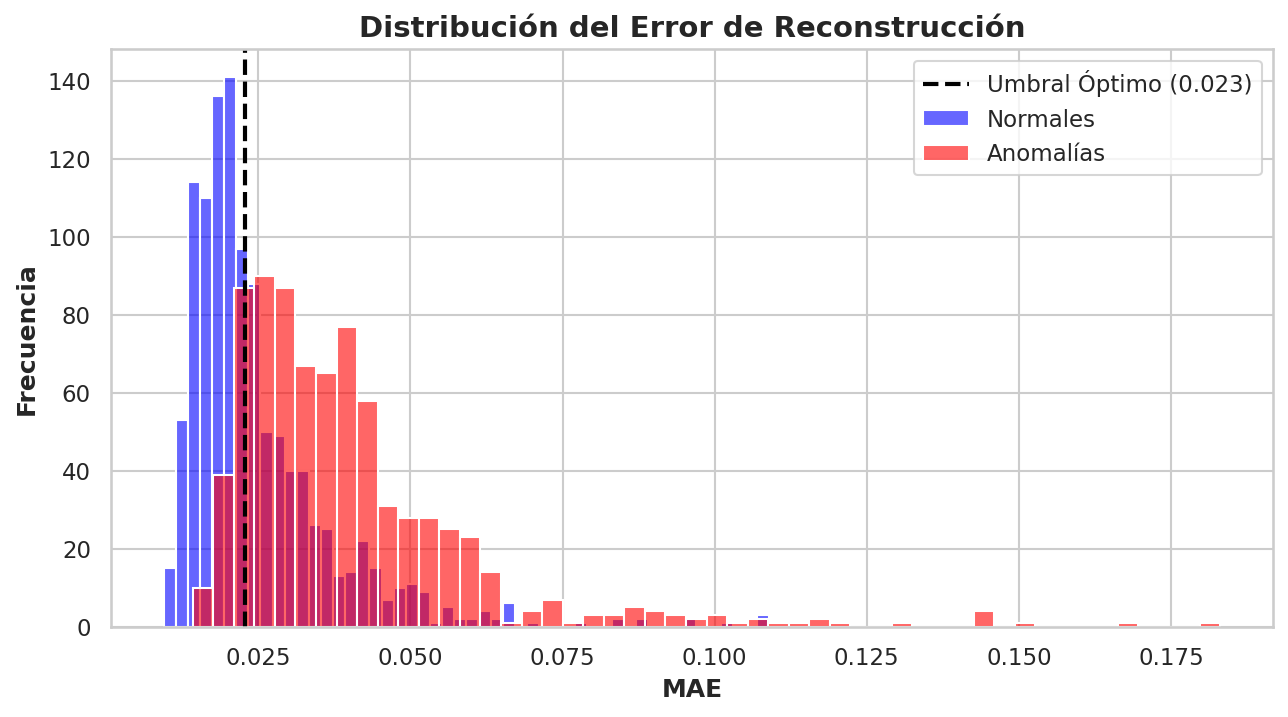


--- Reporte de Clasificación (Umbral Óptimo) ---
              precision    recall  f1-score   support

      Normal       0.88      0.58      0.70      1119
    Anomalía       0.59      0.89      0.71       781

    accuracy                           0.70      1900
   macro avg       0.74      0.73      0.70      1900
weighted avg       0.76      0.70      0.70      1900



In [11]:
precision, recall, thresholds = precision_recall_curve(y_test_binario, errores_test)

# Calculamos el F1-Score para cada umbral
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
idx_optimo = np.argmax(f1_scores)
umbral_optimo = thresholds[idx_optimo]

print(f"Umbral Óptimo (Max F1-Score): {umbral_optimo:.4f}")

# Visualizamos las distribuciones y el umbral
plt.figure(figsize=(10, 5))
sns.histplot(errores_test[y_test_binario == 0], bins=50, color='blue', alpha=0.6, label='Normales')
sns.histplot(errores_test[y_test_binario == 1], bins=50, color='red', alpha=0.6, label='Anomalías')
plt.axvline(umbral_optimo, color='black', linestyle='--', linewidth=2, label=f'Umbral Óptimo ({umbral_optimo:.3f})')
plt.title("Distribución del Error de Reconstrucción")
plt.xlabel("MAE")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

# Evaluamos el rendimiento final
predicciones = (errores_test > umbral_optimo).astype(int)
print("\n--- Reporte de Clasificación (Umbral Óptimo) ---")
print(classification_report(y_test_binario, predicciones, target_names=['Normal', 'Anomalía']))

### Análisis del Rendimiento: La Limitación del Error de Reconstrucción

Si se observa el reporte de clasificación, se podrá notar que el F1-Score ronda el **70%**.
¿Por qué un rendimiento tan mediocre si visualmente el error parecía claro?

Mirar nuevamente el histograma de distribuciones. Aunque la "cola" derecha está llena de anomalías (rojo), hay una **superposición masiva** entre normales y anomalías en la zona de bajo error (MAE entre `0,02` y `0,05`).
El error de reconstrucción es una métrica "bruta" que promedia la falla píxel por píxel (o muestra por muestra). Dos señales pueden tener el mismo MAE promedio, pero formas topológicas completamente distintas. Necesitamos una herramienta más inteligente.

## 7. El Espacio Latente: UMAP, Correlación y el Pipeline Híbrido


El error de reconstrucción falló porque colapsó toda la complejidad de la señal en un solo número (el MAE). Pero el Autoencoder hizo algo mucho más valioso: **comprimió 140 dimensiones en 8 dimensiones de información pura** (el Espacio Latente).

Vamos a extraer estas 8 características y analizarlas:


In [12]:
# 1. Extraemos las características latentes (8 dimensiones)
X_train_latente = encoder.predict(X_train_scaled, verbose=0)
X_test_latente = encoder.predict(X_test_scaled, verbose=0)

# Etiquetas binarias para el train
y_train_binario = (y_train_raw != 1).astype(int)

### A. Análisis de Correlación y "Neuronas Muertas"

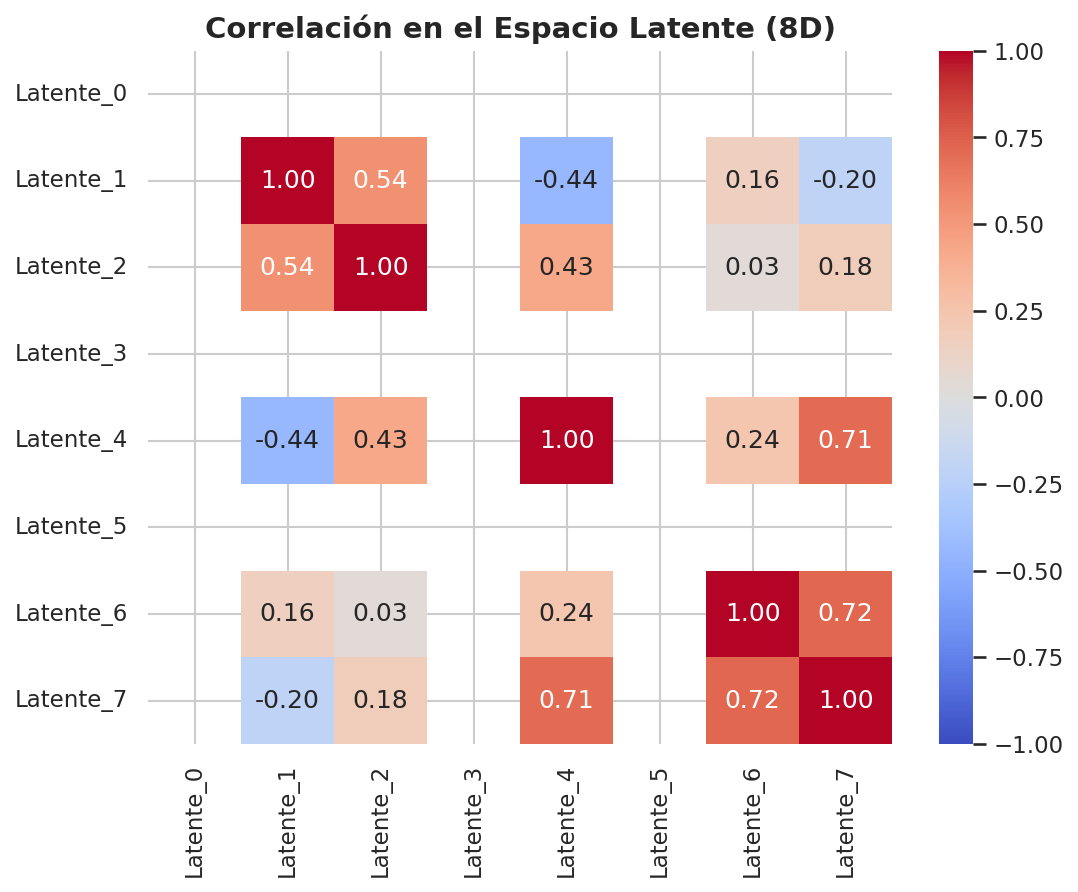

In [13]:
df_latente = pd.DataFrame(X_train_latente, columns=[f"Latente_{i}" for i in range(8)])

plt.figure(figsize=(8, 6))
sns.heatmap(df_latente.corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlación en el Espacio Latente (8D)")
plt.show()

**Lectura de Ingeniería:**  
1. **No linealidad:** A diferencia de PCA (donde todas las componentes tienen correlación 0 por definición matemática), aquí vemos características correlacionadas. El Autoencoder aprendió representaciones no lineales.
2. **Neuronas Muertas:** Es muy común que al inspeccionar este DataFrame se encuentren columnas enteras con ceros (varianza nula, lo que genera `NaN` en la correlación). Esto significa que la red "apagó" ese camino porque no lo necesitaba. (*Probar de entrenar nuevamente la misma arquitectura y visualizar la gráfica...*)

> **Nota:** Las redes neuronales son estocásticas. Si se cambia la semilla (`seed`), la red convergerá a un espacio latente distinto, apagando diferentes neuronas. Si se ven muchas neuronas muertas, es una señal de que se puede comprimir aún más el cuello de botella (ej. a 4 dimensiones).

### B. Visualización Topológica con UMAP

Si el espacio latente es bueno, las anomalías deberían estar separadas de los datos normales, incluso si su error de reconstrucción era similar. UMAP nos permite visualizar estas 8 dimensiones en 2D.

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


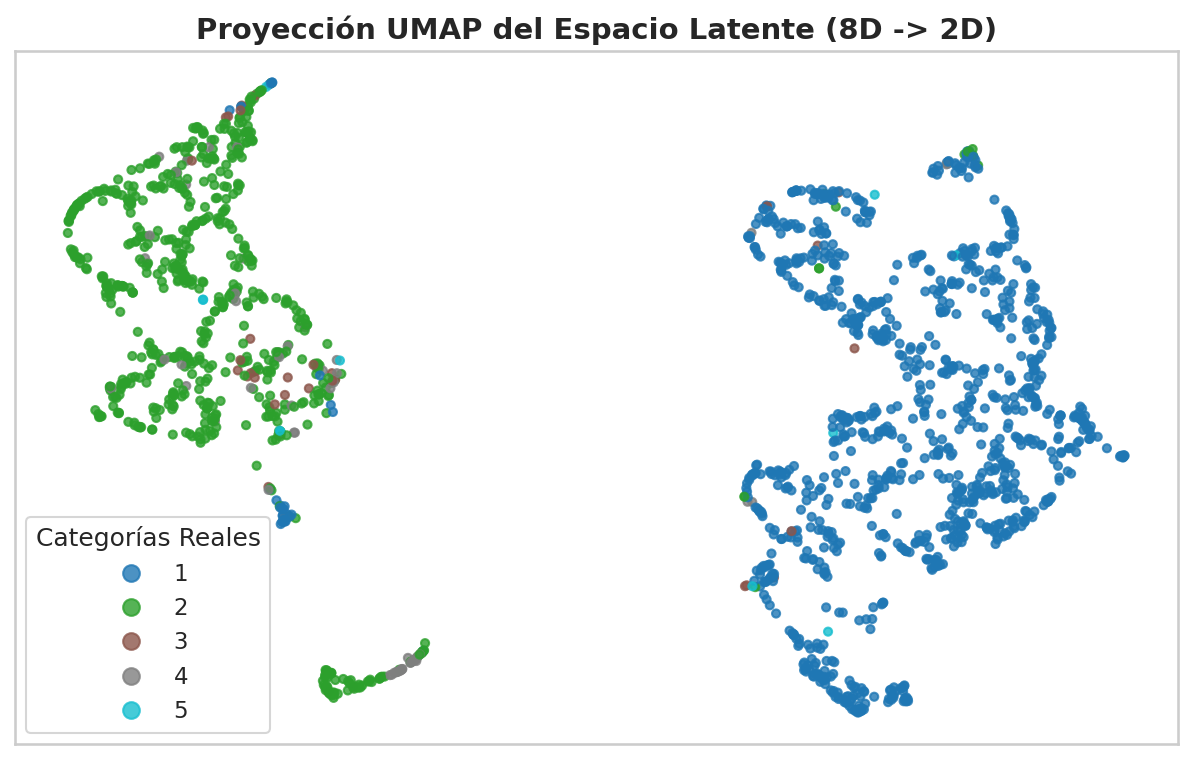

In [14]:
import umap

reducer = umap.UMAP(random_state=42)
embedding_latente = reducer.fit_transform(X_test_latente)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(embedding_latente[:, 0], embedding_latente[:, 1],
                      c=y_test_raw, cmap='tab10', s=15, alpha=0.8)
plt.title("Proyección UMAP del Espacio Latente (8D -> 2D)")
plt.legend(*scatter.legend_elements(), title="Categorías Reales")
plt.xticks([]); plt.yticks([])
plt.show()

¡Observar la magia! La Categoría 1 (Normal) forma una isla densa, mientras que las anomalías (Categorías 2, 3, 4, 5) se separan en clústeres distintos. El Autoencoder **organizó la topología de los datos**, algo que el simple MAE no podía ver.

### C. El Pipeline Híbrido (Deep Learning + ML Clásico)

Aprovechando esta separación casi perfecta, entrenamos una Regresión Logística clásica sobre estas 8 características.

In [15]:
from sklearn.linear_model import LogisticRegression

# Entrenamos un modelo clásico sobre el espacio latente
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_latente, y_train_binario)

# Evaluamos
pred_hibridas = clf.predict(X_test_latente)
print("--- Reporte de Clasificación (Pipeline Híbrido: Encoder + Regresión Logística) ---")
print(classification_report(y_test_binario, pred_hibridas, target_names=['Normal', 'Anomalía']))

--- Reporte de Clasificación (Pipeline Híbrido: Encoder + Regresión Logística) ---
              precision    recall  f1-score   support

      Normal       0.97      0.98      0.98      1119
    Anomalía       0.97      0.96      0.96       781

    accuracy                           0.97      1900
   macro avg       0.97      0.97      0.97      1900
weighted avg       0.97      0.97      0.97      1900



**Veredicto:** Pasamos de un F1-Score del **70%** (usando el umbral de error) a un **97%**. La red neuronal hizo el trabajo pesado de extracción de características (*Feature Engineering*), y el modelo clásico trazó la frontera de decisión.


> **🧠 Mención Teórica Avanzada:**
> En problemas extremadamente complejos, el error de reconstrucción puede fallar. Una técnica de vanguardia es proyectar los datos al espacio latente de 8 dimensiones y aplicar algoritmos como **Isolation Forest** o calcular la **Distancia de Mahalanobis** directamente allí. Al haber eliminado el ruido de las 140 dimensiones originales, estos algoritmos clásicos se vuelven exponencialmente más precisos.



## 8. Variantes Avanzadas

El Autoencoder que construimos hoy es la versión más básica (*Undercomplete Autoencoder*). En la industria, existen dos variantes fundamentales que resuelven problemas más complejos:

1. **Denoising Autoencoders (DAE):**
   En lugar de pasarle la señal limpia, le inyectamos ruido artificial (ej. estática) a la entrada, pero le pedimos que reconstruya la señal *limpia* en la salida. Esto obliga a la red a aprender la estructura fundamental de los datos en lugar de simplemente memorizarlos, haciéndola extremadamente robusta.
2. **Variational Autoencoders (VAE):**
   Nuestro Autoencoder mapea cada ECG a un punto fijo en el espacio latente. Un VAE mapea cada ECG a una *distribución de probabilidad* (una media y una varianza). Esto convierte al VAE en un **Modelo Generativo**. Si se toma un punto aleatorio del espacio latente de un VAE y se lo pasa por el Decoder, la red "alucinará" un latido cardíaco completamente nuevo y realista que nunca existió.

## 9. Consideraciones de Despliegue



En producción, no se necesita guardar el Autoencoder completo si solo se va a usar el Pipeline Híbrido. Podemos guardar únicamente el `Encoder` y el modelo de `scikit-learn`.

In [16]:
# Guardamos el modelo en el formato moderno de Keras
encoder.save("ecg_encoder_feature_extractor.keras")
autoencoder.save("ecg_autoencoder_completo.keras")
print("Modelos guardados exitosamente para producción.")

Modelos guardados exitosamente para producción.


## Conexiones y Próximos Pasos


Cerramos la brecha entre el Machine Learning clásico y el Deep Learning. Aprendimos que las redes neuronales no solo sirven para clasificar, sino para **aprender representaciones** (*Representation Learning*) robustas incluso frente a datos contaminados.

- ➡️ **Siguiente:** Dejamos los datos tabulares y secuenciales simples para entrar al mundo de la Visión por Computadora. En el notebook [Redes Convolucionales (CNN)](09_redes_convolucionales_cnn.ipynb), aprendemos cómo extraer características espaciales jerárquicas.
- 🔄 **Relacionado:** La técnica de usar una red pre-entrenada como extractor de características que vimos hoy es la base absoluta del [Transfer Learning y Fine-Tuning](12_transfer_learning_y_fine_tuning.ipynb).



## Referencias


### Artículos y Libros Fundacionales

1. **Goodfellow, I., Bengio, Y., & Courville, A. (2016)**. *Deep Learning* (Capítulo 14: Autoencoders). MIT Press.  
   Disponible gratis en [deeplearningbook.org](https://www.deeplearningbook.org/)  

2. **Kingma, D. P., & Welling, M. (2013)**. *Auto-Encoding Variational Bayes*. arXiv preprint.  
   [[arXiv]](https://arxiv.org/abs/1312.6114)  
   (Paper original de Variational Autoencoders — siguiente nivel después de este notebook).

3. **An, J., & Cho, S. (2015)**. *Variational Autoencoder based Anomaly Detection using Reconstruction Probability*.  
   (Uno de los trabajos clásicos sobre detección de anomalías con Autoencoders).

### Recursos Prácticos

- **Chollet, F. (2021)**. *Deep Learning with Python, Second Edition* (Capítulo sobre Autoencoders). Manning.
- **Keras Official Tutorial**: [Building Autoencoders in Keras](https://blog.keras.io/building-autoencoders-in-keras.html).
- Dataset ECG5000: Goldberger et al. (2000). PhysioNet.  
  [[PhysioNet]](https://physionet.org/content/ptbdb/1.0.0/)

### Recursos Visuales
- Ejemplo interactivo de todo esto: https://anomagram.fastforwardlabs.com/#/

---


## Entorno de Ejecución


In [17]:
from utils.environment import environment_table
environment_table(include_all=True)

Package,Version
Python,3.12.13
Platform,Linux-6.6.122+-x86_64-with-glibc2.35
Cython,3.0.12
IPython,7.34.0
OpenSSL,24.2.1
PIL,11.3.0
anywidget,0.9.21
argparse,1.1
astunparse,1.6.3
attr,26.1.0
